# SETUP

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Importing Libraries</b>
</div>

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# LOADING DATASET

In [31]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
df = pd.read_csv(url, header=None)

print("Shape:", df.shape)
print(df.head())

Shape: (303, 14)
     0    1    2      3      4    5    6      7    8    9    10   11   12  13
0  63.0  1.0  1.0  145.0  233.0  1.0  2.0  150.0  0.0  2.3  3.0  0.0  6.0   0
1  67.0  1.0  4.0  160.0  286.0  0.0  2.0  108.0  1.0  1.5  2.0  3.0  3.0   2
2  67.0  1.0  4.0  120.0  229.0  0.0  2.0  129.0  1.0  2.6  2.0  2.0  7.0   1
3  37.0  1.0  3.0  130.0  250.0  0.0  0.0  187.0  0.0  3.5  3.0  0.0  3.0   0
4  41.0  0.0  2.0  130.0  204.0  0.0  2.0  172.0  0.0  1.4  1.0  0.0  3.0   0


# 1. Handle Missing Values (in this dataset, "?" is used)

In [32]:
df = df.replace("?", np.nan)
df = df.dropna()  
df = df.astype(float)

# 2. Separate features and target

In [33]:
X = df.iloc[:, :-1]  
y = df.iloc[:, -1]

# 3. Standardize Features


In [34]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Apply PCA

In [35]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# 5. Explained Variance


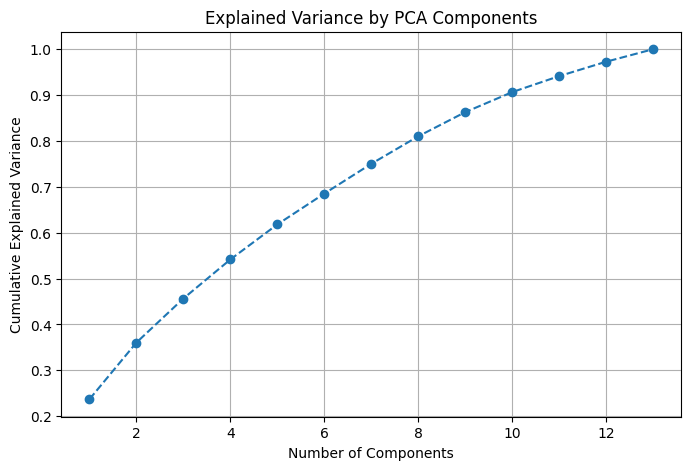

Explained variance ratio per component: [0.23695056 0.12349486 0.0960383  0.0851614  0.07638123 0.06720242
 0.06493755 0.05994447 0.05268635 0.04368496 0.03486402 0.03140469
 0.02724919]
Cumulative variance: [0.23695056 0.36044542 0.45648373 0.54164513 0.61802636 0.68522878
 0.75016633 0.8101108  0.86279714 0.9064821  0.94134612 0.97275081
 1.        ]


In [36]:
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', linestyle='--')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Cumulative variance:", explained_var)

# 6. Choose optimal components (e.g., 95% variance)


In [37]:
pca_opt = PCA(n_components=0.95)  # keep 95% variance
X_pca_opt = pca_opt.fit_transform(X_scaled)

print("Optimal number of components:", pca_opt.n_components_)
print("Transformed dataset shape:", X_pca_opt.shape)

Optimal number of components: 12
Transformed dataset shape: (297, 12)


# 7. Scatter plot (first 2 components for visualization)


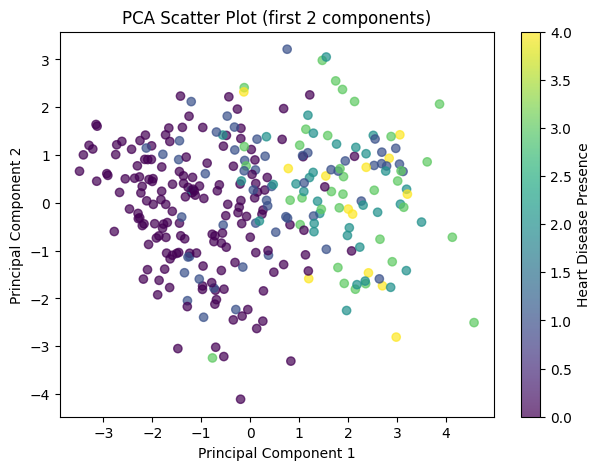

In [38]:
plt.figure(figsize=(7,5))
plt.scatter(X_pca_opt[:,0], X_pca_opt[:,1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Scatter Plot (first 2 components)")
plt.colorbar(label="Heart Disease Presence")
plt.show()